# ETCXGB — Full Pipeline Explainability
> **Dataset schema:** age · sex · cp · trestbps · chol · fbs · restecg · thalach · exang · oldpeak · slope · ca · thal · target  
> **Stage 1:** ExtraTreesClassifier (ETC) on 13 original features  
> **Stage 2:** XGBoost on 13 features + ET_Probability (14 total)  
> **Coverage:** Confusion Matrix · ROC · ETC Explainability · XGB Explainability · Pipeline Analysis · Medical Insights

## 0. Setup

In [ ]:
!pip install xgboost imbalanced-learn shap lime --quiet

In [ ]:
import math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
)
from xgboost import XGBClassifier

import shap
from lime import lime_tabular

print("All imports OK")

All imports OK


## 1. Load Data, Build Pipeline & Evaluate

In [ ]:
# ── Load ──────────────────────────────────────────────────────────
# Column names already match the standard short aliases — no renaming needed
FILE_PATH = '/content/dataset (2).csv'   # ← update to your filename

data = pd.read_csv(FILE_PATH)

# Sanity check
EXPECTED_COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
                 'thalach','exang','oldpeak','slope','ca','thal','target']
assert list(data.columns) == EXPECTED_COLS, f"Column mismatch: {data.columns.tolist()}"

print("Shape          :", data.shape)
print("Missing values :", data.isnull().sum().sum(), "(expected 0)")
print("Target dist    :\n", data['target'].value_counts())
data.head()

Shape          : (1025, 14)
Missing values : 0 (expected 0)
Target dist    :
 target
1    526
0    499
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# ── Feature / Target split ────────────────────────────────────────
FEATURE_COLS = [c for c in data.columns if c != 'target']
X = data[FEATURE_COLS].values
y = data['target'].values

# ── Split → Scale ────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print(f"Train: {X_train_scaled.shape} | Test: {X_test_raw.shape}")
print(f"Class balance — Train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class balance — Test : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

# ── Stage 1 : ExtraTreesClassifier ───────────────────────────────
ET = ExtraTreesClassifier(n_estimators=200, random_state=42)
ET.fit(X_train_scaled, y_train)

ET_train_prob = ET.predict_proba(X_train_scaled)[:, 1]
ET_test_prob  = ET.predict_proba(X_test_scaled)[:, 1]
ET_pred       = ET.predict(X_test_scaled)

# ── Stage 2 : XGBoost on hybrid features ─────────────────────────
X_train_h = np.column_stack((X_train_scaled, ET_train_prob))
X_test_h  = np.column_stack((X_test_scaled, ET_test_prob))

HYBRID_NAMES = FEATURE_COLS + ['ET_Probability']   # 14 features total

xgb_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train_h, y_train)

xgb_pred = xgb_model.predict(X_test_h)
xgb_prob = xgb_model.predict_proba(X_test_h)[:, 1]

# ── Metrics ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, xgb_pred)
TN, FP, FN, TP = cm.ravel()

accuracy    = accuracy_score(y_test, xgb_pred)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
mcc         = ((TP*TN) - (FP*FN)) / math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
roc_auc     = roc_auc_score(y_test, xgb_prob)

print("=" * 50)
print("  ETCXGB Pipeline — Results")
print("=" * 50)
print(f"  Accuracy    : {accuracy:.4f}")
print(f"  Sensitivity : {sensitivity:.4f}")
print(f"  Specificity : {specificity:.4f}")
print(f"  MCC         : {mcc:.4f}")
print(f"  ROC-AUC     : {roc_auc:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, xgb_pred, target_names=['No Disease', 'Disease']))

Train: (717, 13) | Test: (308, 13)
Class balance — Train: {np.int64(0): np.int64(349), np.int64(1): np.int64(368)}
Class balance — Test : {np.int64(0): np.int64(150), np.int64(1): np.int64(158)}
  ETCXGB Pipeline — Results
  Accuracy    : 0.9481
  Sensitivity : 0.8987
  Specificity : 1.0000
  MCC         : 0.9012
  ROC-AUC     : 0.9908

              precision    recall  f1-score   support

  No Disease       0.90      1.00      0.95       150
     Disease       1.00      0.90      0.95       158

    accuracy                           0.95       308
   macro avg       0.95      0.95      0.95       308
weighted avg       0.95      0.95      0.95       308



## 2. Confusion Matrix & ROC Curve

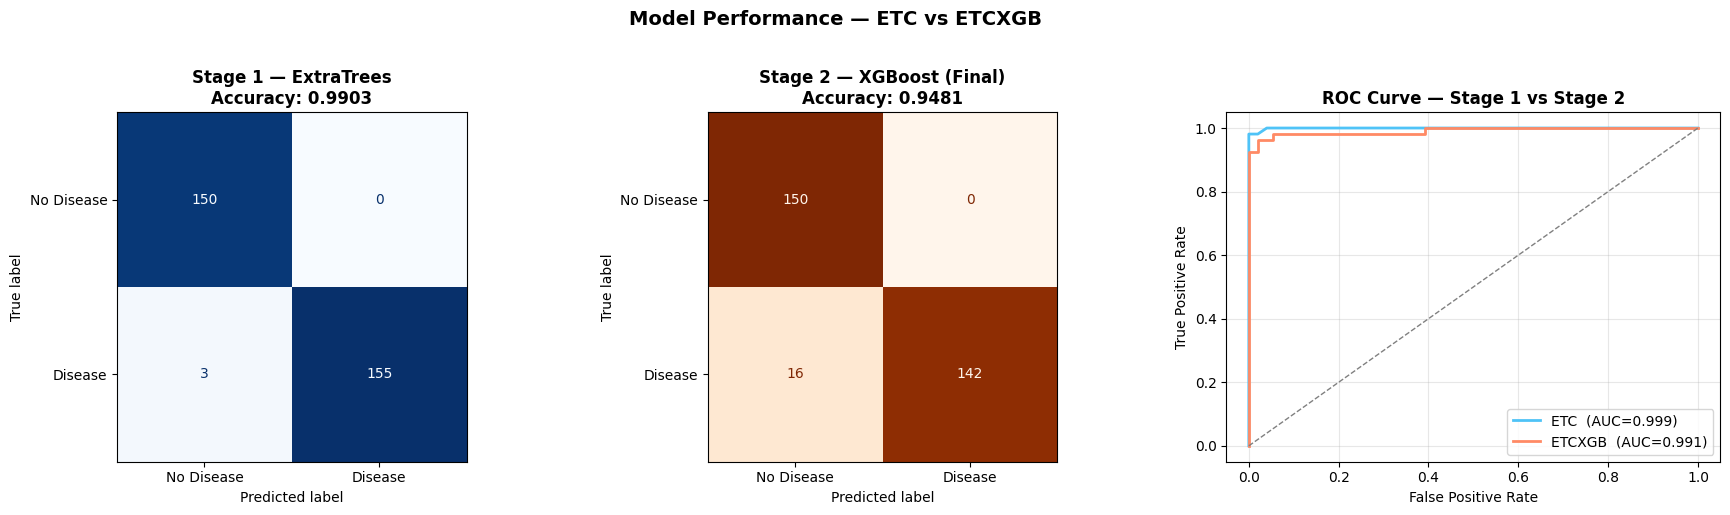

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stage 1 — ETC
cm_et = confusion_matrix(y_test, ET_pred)
ConfusionMatrixDisplay(cm_et, display_labels=['No Disease','Disease']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(
    f'Stage 1 — ExtraTrees\nAccuracy: {accuracy_score(y_test, ET_pred):.4f}',
    fontweight='bold'
)

# Stage 2 — XGB
ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease']).plot(
    ax=axes[1], cmap='Oranges', colorbar=False
)
axes[1].set_title(
    f'Stage 2 — XGBoost (Final)\nAccuracy: {accuracy:.4f}',
    fontweight='bold'
)

# ROC — both stages
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_et,  tpr_et,  _ = roc_curve(y_test, ET.predict_proba(X_test_scaled)[:,1])
auc_et = roc_auc_score(y_test, ET.predict_proba(X_test_scaled)[:,1])

axes[2].plot(fpr_et,  tpr_et,  color='#4fc3f7', lw=2, label=f'ETC  (AUC={auc_et:.3f})')
axes[2].plot(fpr_xgb, tpr_xgb, color='#ff8a65', lw=2, label=f'ETCXGB  (AUC={roc_auc:.3f})')
axes[2].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve — Stage 1 vs Stage 2', fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Model Performance — ETC vs ETCXGB', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('performance_cm_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Compute SHAP Values (Both Stages)

In [ ]:
# ETC SHAP — returns (n_samples, n_features, 2); index [:,: ,1] = Disease class
shap_et      = shap.TreeExplainer(ET)
sv_et        = shap_et.shap_values(X_test_scaled)
sv_et_class1 = sv_et[:, :, 1]
ev_et        = shap_et.expected_value[1]

# XGB SHAP
shap_xgb  = shap.TreeExplainer(xgb_model)
sv_xgb    = shap_xgb.shap_values(X_test_h)
ev_xgb    = shap_xgb.expected_value

print(f"ETC  SHAP shape : {sv_et_class1.shape}  (13 original features)")
print(f"XGB  SHAP shape : {sv_xgb.shape}         (13 + ET_Probability)")

ETC  SHAP shape : (308, 13)  (13 original features)
XGB  SHAP shape : (308, 14)         (13 + ET_Probability)


---
## 4. Stage 1 Explainability — ExtraTreesClassifier
ETC operates on all 13 original features. Its output (`ET_Probability`) feeds directly into Stage 2.

### 4a. ETC Native Feature Importance

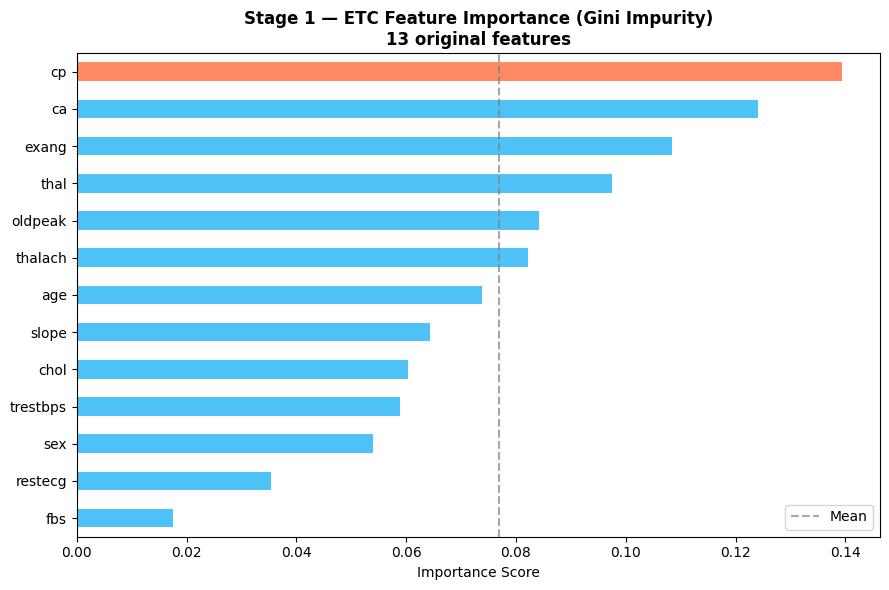

In [ ]:
et_imp = pd.Series(ET.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors  = ['#ff8a65' if v == et_imp.max() else '#4fc3f7' for v in et_imp]
et_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.axvline(et_imp.mean(), linestyle='--', color='gray', alpha=0.7, label='Mean')
ax.set_title('Stage 1 — ETC Feature Importance (Gini Impurity)\n13 original features',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.savefig('etc_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 4b. ETC SHAP Beeswarm

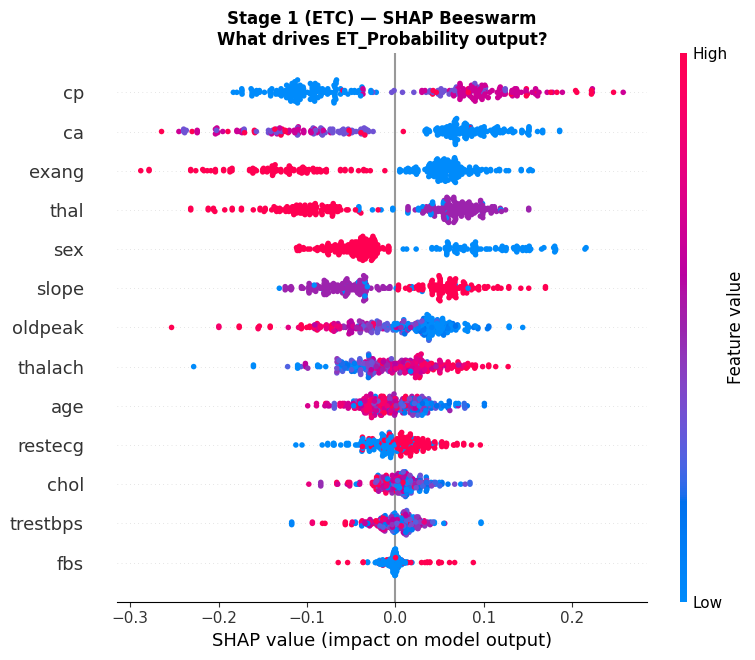

In [ ]:
shap.summary_plot(
    sv_et_class1, X_test_scaled,
    feature_names=FEATURE_COLS,
    plot_type='dot', show=False
)
plt.title('Stage 1 (ETC) — SHAP Beeswarm\nWhat drives ET_Probability output?',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('etc_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 4c. ETC SHAP Waterfall — Single Patient

Patient 5 | Actual: Disease
ETC  probability : 1.0000
XGB  probability : 0.9973


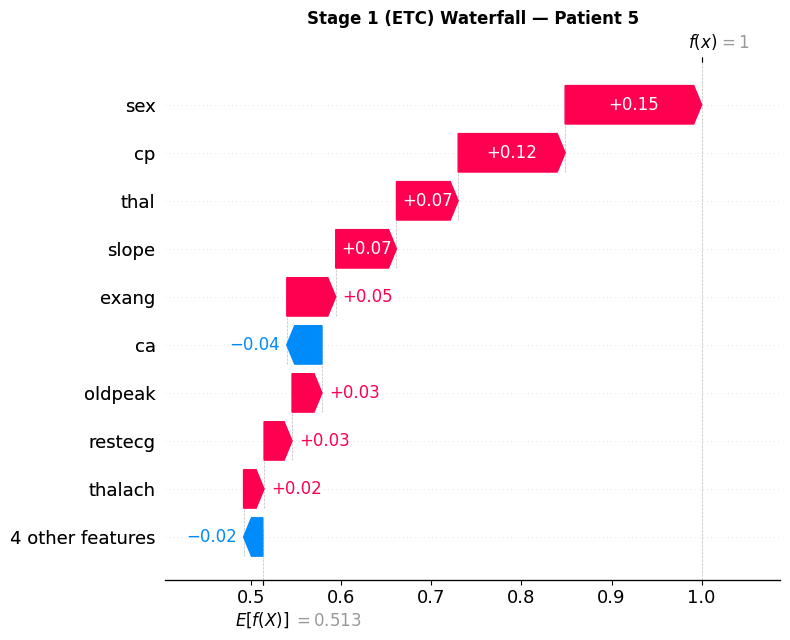

In [ ]:
PATIENT_INDEX = 5   # change to inspect a different patient

print(f"Patient {PATIENT_INDEX} | Actual: {'Disease' if y_test[PATIENT_INDEX]==1 else 'No Disease'}")
print(f"ETC  probability : {ET_test_prob[PATIENT_INDEX]:.4f}")
print(f"XGB  probability : {xgb_prob[PATIENT_INDEX]:.4f}")

shap.plots._waterfall.waterfall_legacy(
    ev_et, sv_et_class1[PATIENT_INDEX],
    feature_names=FEATURE_COLS, show=False
)
plt.title(f'Stage 1 (ETC) Waterfall — Patient {PATIENT_INDEX}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'etc_waterfall_p{PATIENT_INDEX}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Stage 2 Explainability — XGBoost
XGBoost sees 14 features: 13 original + ET_Probability.

### 5a. XGB Feature Importance — Gain

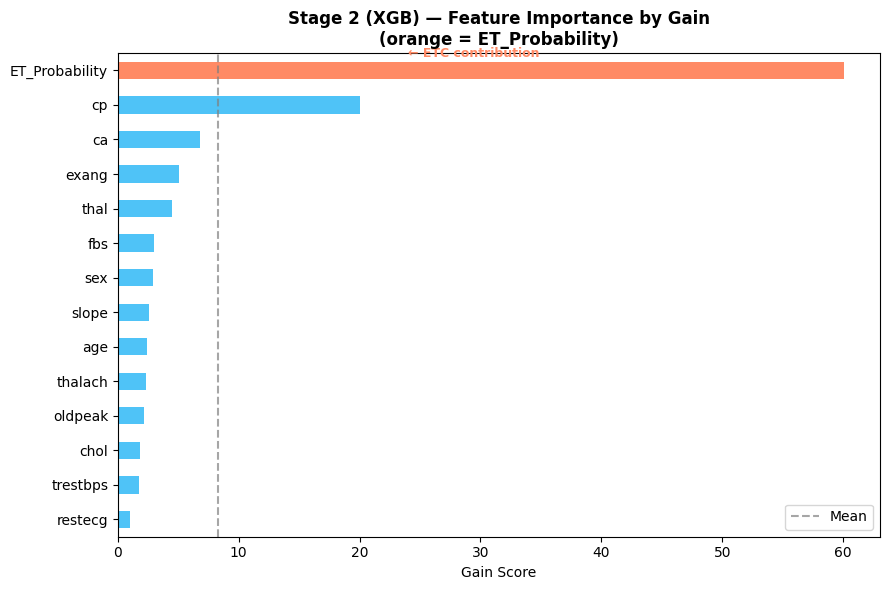

In [ ]:
scores   = xgb_model.get_booster().get_score(importance_type='gain')
readable = {f'f{i}': name for i, name in enumerate(HYBRID_NAMES)}
scores   = {readable.get(k, k): v for k, v in scores.items()}
df_gain  = pd.Series(scores).sort_values(ascending=True)

colors = ['#ff8a65' if 'ET_Probability' in k else '#4fc3f7' for k in df_gain.index]

fig, ax = plt.subplots(figsize=(9, 6))
df_gain.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.axvline(df_gain.mean(), linestyle='--', color='gray', alpha=0.7, label='Mean')
if 'ET_Probability' in df_gain.index:
    idx = list(df_gain.index).index('ET_Probability')
    ax.annotate('← ETC contribution', xy=(df_gain['ET_Probability'], idx),
                xytext=(df_gain['ET_Probability']*0.4, idx+0.4),
                fontsize=9, color='#ff8a65', fontweight='bold')
ax.set_title('Stage 2 (XGB) — Feature Importance by Gain\n(orange = ET_Probability)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Gain Score')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b. XGB SHAP Beeswarm

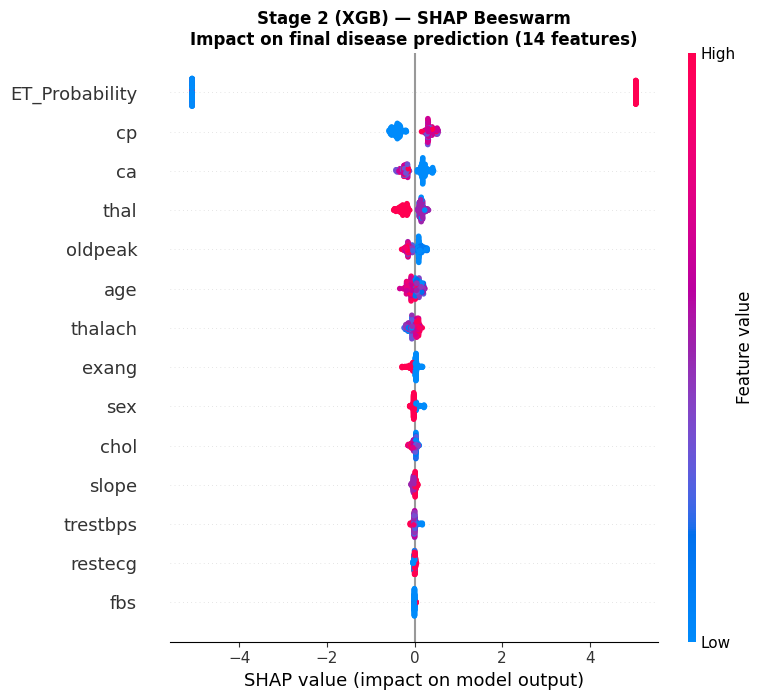

In [ ]:
shap.summary_plot(
    sv_xgb, X_test_h,
    feature_names=HYBRID_NAMES,
    plot_type='dot', show=False
)
plt.title('Stage 2 (XGB) — SHAP Beeswarm\nImpact on final disease prediction (14 features)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 5c. XGB SHAP Waterfall — Same Patient

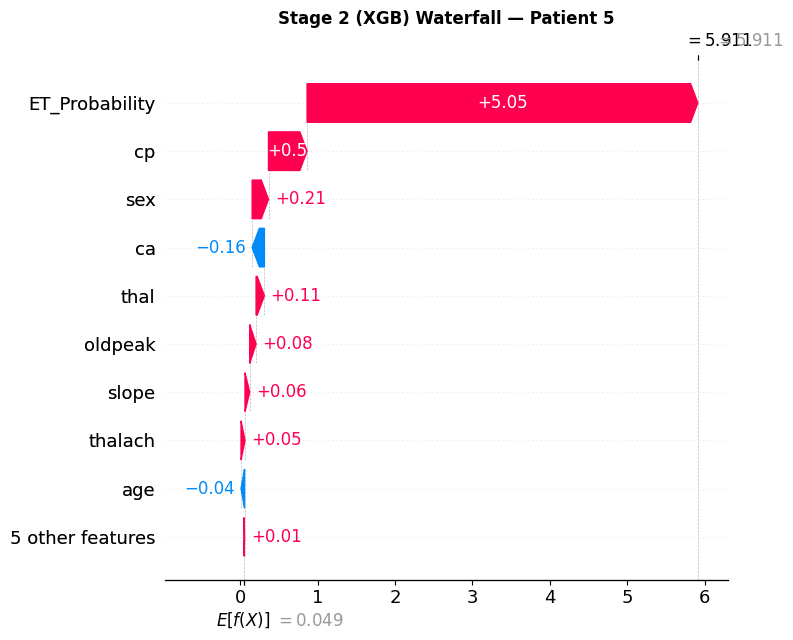

In [ ]:
shap.plots._waterfall.waterfall_legacy(
    ev_xgb, sv_xgb[PATIENT_INDEX],
    feature_names=HYBRID_NAMES, show=False
)
plt.title(f'Stage 2 (XGB) Waterfall — Patient {PATIENT_INDEX}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'xgb_waterfall_p{PATIENT_INDEX}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Pipeline-Level Explainability

### 6a. SHAP Importance Shift — Stage 1 vs Stage 2 (Same 13 Features)

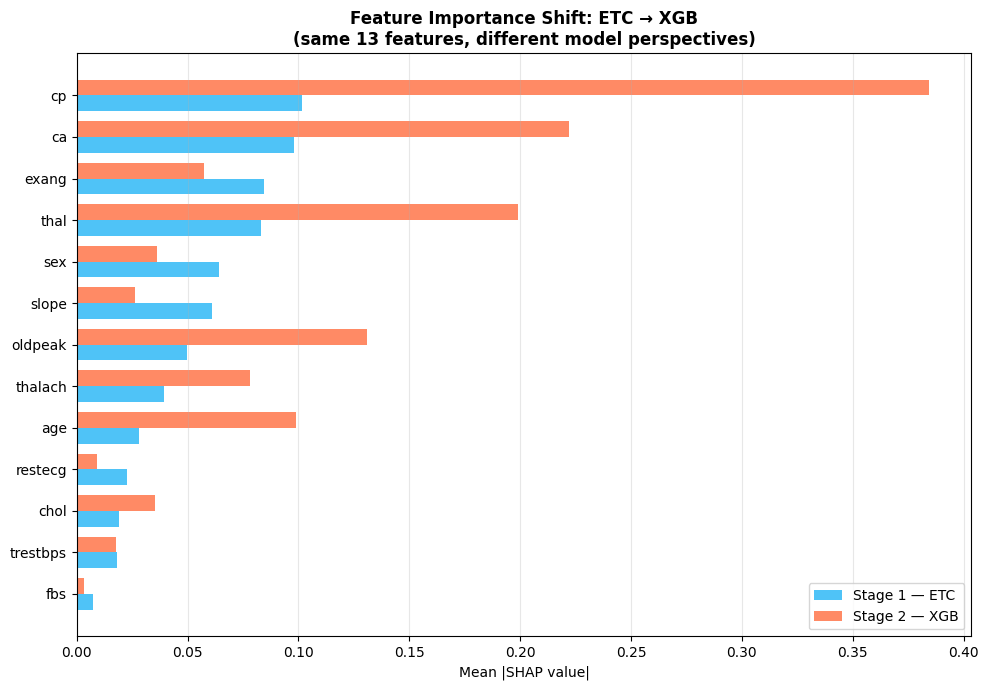

In [ ]:
mean_shap_et  = np.abs(sv_et_class1).mean(axis=0)
mean_shap_xgb = np.abs(sv_xgb[:, :13]).mean(axis=0)   # first 13 = original features

df_compare = pd.DataFrame({
    'Stage 1 (ETC)': mean_shap_et,
    'Stage 2 (XGB)': mean_shap_xgb,
}, index=FEATURE_COLS).sort_values('Stage 1 (ETC)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
x, width = np.arange(len(df_compare)), 0.38
ax.barh(x - width/2, df_compare['Stage 1 (ETC)'], width,
        label='Stage 1 — ETC', color='#4fc3f7', edgecolor='none')
ax.barh(x + width/2, df_compare['Stage 2 (XGB)'], width,
        label='Stage 2 — XGB', color='#ff8a65', edgecolor='none')
ax.set_yticks(x); ax.set_yticklabels(df_compare.index)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance Shift: ETC → XGB\n(same 13 features, different model perspectives)',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('pipeline_shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6b. ET_Probability Contribution to XGB Decisions

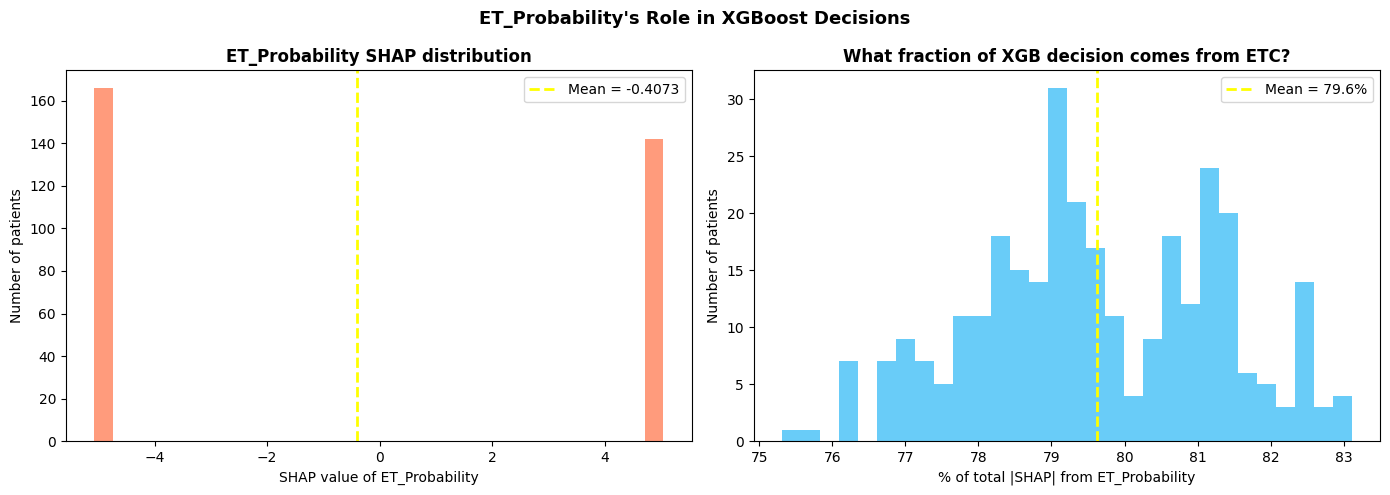

Average % of decision from ETC : 79.6%
Patients where ETC dominant (>30%): 308 / 308


In [ ]:
et_prob_shap = sv_xgb[:, -1]
total_abs    = np.abs(sv_xgb).sum(axis=1)
et_fraction  = np.abs(et_prob_shap) / total_abs * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(et_prob_shap, bins=30, color='#ff8a65', edgecolor='none', alpha=0.85)
axes[0].axvline(0, color='white', lw=1.5, linestyle='--')
axes[0].axvline(et_prob_shap.mean(), color='yellow', lw=2, linestyle='--',
                label=f'Mean = {et_prob_shap.mean():.4f}')
axes[0].set_xlabel('SHAP value of ET_Probability')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('ET_Probability SHAP distribution', fontweight='bold')
axes[0].legend()

axes[1].hist(et_fraction, bins=30, color='#4fc3f7', edgecolor='none', alpha=0.85)
axes[1].axvline(et_fraction.mean(), color='yellow', lw=2, linestyle='--',
                label=f'Mean = {et_fraction.mean():.1f}%')
axes[1].set_xlabel('% of total |SHAP| from ET_Probability')
axes[1].set_ylabel('Number of patients')
axes[1].set_title('What fraction of XGB decision comes from ETC?', fontweight='bold')
axes[1].legend()

plt.suptitle("ET_Probability's Role in XGBoost Decisions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pipeline_et_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average % of decision from ETC : {et_fraction.mean():.1f}%")
print(f"Patients where ETC dominant (>30%): {(et_fraction>30).sum()} / {len(et_fraction)}")

### 6c. Agreement Analysis — Where ETC and XGB Disagree

Agreed   : 295 patients
Disagreed: 13 patients
  ETC correct  : 13
  XGB correct  : 0
  Both wrong   : 0


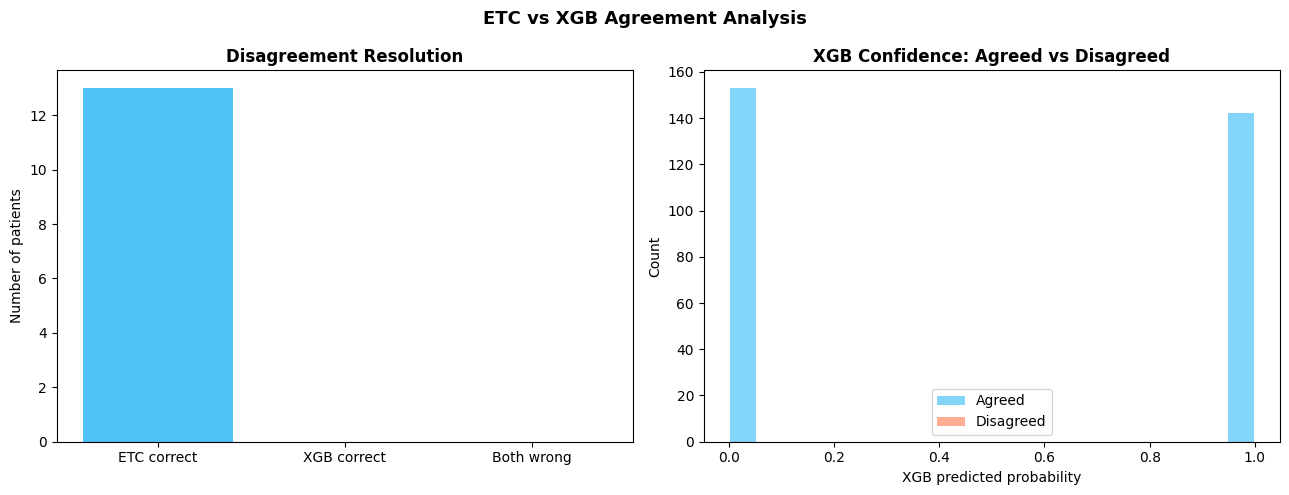

In [ ]:
disagree_mask = (ET_pred != xgb_pred)
etc_right     = (ET_pred[disagree_mask] == y_test[disagree_mask]).sum()
xgb_right     = (xgb_pred[disagree_mask] == y_test[disagree_mask]).sum()
both_wrong    = disagree_mask.sum() - etc_right - xgb_right

print(f"Agreed   : {(~disagree_mask).sum()} patients")
print(f"Disagreed: {disagree_mask.sum()} patients")
print(f"  ETC correct  : {etc_right}")
print(f"  XGB correct  : {xgb_right}")
print(f"  Both wrong   : {both_wrong}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['ETC correct','XGB correct','Both wrong'],
            [etc_right, xgb_right, both_wrong],
            color=['#4fc3f7','#ff8a65','#aaaaaa'], edgecolor='none')
axes[0].set_title('Disagreement Resolution', fontweight='bold')
axes[0].set_ylabel('Number of patients')

axes[1].hist(xgb_prob[~disagree_mask], bins=20, alpha=0.7,
             color='#4fc3f7', label='Agreed', edgecolor='none')
axes[1].hist(xgb_prob[disagree_mask],  bins=20, alpha=0.7,
             color='#ff8a65', label='Disagreed', edgecolor='none')
axes[1].set_xlabel('XGB predicted probability')
axes[1].set_ylabel('Count')
axes[1].set_title('XGB Confidence: Agreed vs Disagreed', fontweight='bold')
axes[1].legend()

plt.suptitle('ETC vs XGB Agreement Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pipeline_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

### 6d. Dual Waterfall — Same Patient Through Both Stages

Patient 7 | Actual: Disease
ETC  → Disease (p=0.8650)
XGB  → No Disease (p=0.0117)


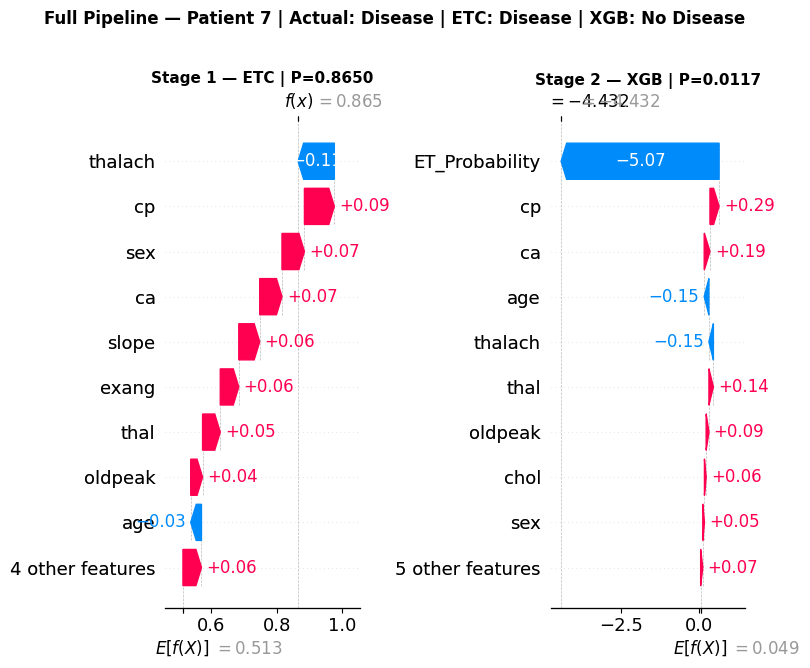

In [ ]:
disagree_indices = np.where(ET_pred != xgb_pred)[0]
DUAL_PATIENT     = disagree_indices[0] if len(disagree_indices) > 0 else PATIENT_INDEX

print(f"Patient {DUAL_PATIENT} | Actual: {'Disease' if y_test[DUAL_PATIENT]==1 else 'No Disease'}")
print(f"ETC  → {'Disease' if ET_pred[DUAL_PATIENT]==1 else 'No Disease'} (p={ET_test_prob[DUAL_PATIENT]:.4f})")
print(f"XGB  → {'Disease' if xgb_pred[DUAL_PATIENT]==1 else 'No Disease'} (p={xgb_prob[DUAL_PATIENT]:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

plt.sca(axes[0])
shap.plots._waterfall.waterfall_legacy(
    ev_et, sv_et_class1[DUAL_PATIENT],
    feature_names=FEATURE_COLS, show=False
)
axes[0].set_title(
    f'Stage 1 — ETC | P={ET_test_prob[DUAL_PATIENT]:.4f}',
    fontsize=11, fontweight='bold'
)

plt.sca(axes[1])
shap.plots._waterfall.waterfall_legacy(
    ev_xgb, sv_xgb[DUAL_PATIENT],
    feature_names=HYBRID_NAMES, show=False
)
axes[1].set_title(
    f'Stage 2 — XGB | P={xgb_prob[DUAL_PATIENT]:.4f}',
    fontsize=11, fontweight='bold'
)

plt.suptitle(
    f'Full Pipeline — Patient {DUAL_PATIENT} | '
    f'Actual: {"Disease" if y_test[DUAL_PATIENT]==1 else "No Disease"} | '
    f'ETC: {"Disease" if ET_pred[DUAL_PATIENT]==1 else "No Disease"} | '
    f'XGB: {"Disease" if xgb_pred[DUAL_PATIENT]==1 else "No Disease"}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'pipeline_dual_waterfall_p{DUAL_PATIENT}.png', dpi=150, bbox_inches='tight')
plt.show()

### 6e. Dual LIME — Both Stages for Same Patient

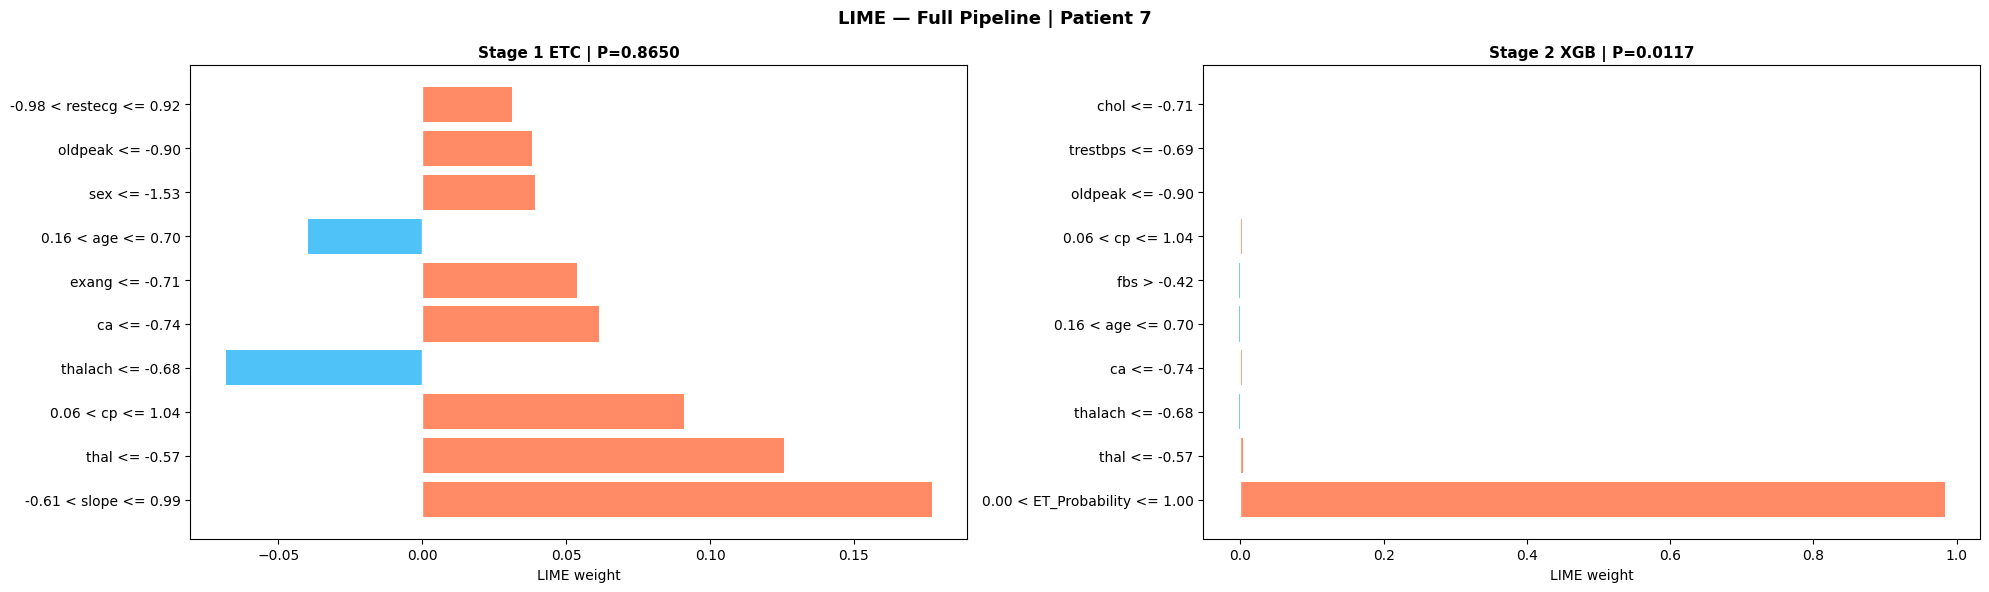

In [ ]:
lime_et_exp = lime_tabular.LimeTabularExplainer(
    X_train_scaled, feature_names=FEATURE_COLS,
    class_names=['No Disease','Disease'], mode='classification', random_state=42
)
lime_xgb_exp = lime_tabular.LimeTabularExplainer(
    X_train_h, feature_names=HYBRID_NAMES,
    class_names=['No Disease','Disease'], mode='classification', random_state=42
)

exp_et  = lime_et_exp.explain_instance(X_test_scaled[DUAL_PATIENT],
                                        ET.predict_proba, num_features=10)
exp_xgb = lime_xgb_exp.explain_instance(X_test_h[DUAL_PATIENT],
                                          xgb_model.predict_proba, num_features=10)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, exp, title in zip(axes,
    [exp_et, exp_xgb],
    [f'Stage 1 ETC | P={ET_test_prob[DUAL_PATIENT]:.4f}',
     f'Stage 2 XGB | P={xgb_prob[DUAL_PATIENT]:.4f}']
):
    vals   = exp.as_list()
    labels = [v[0] for v in vals]
    scores = [v[1] for v in vals]
    colors = ['#ff8a65' if s > 0 else '#4fc3f7' for s in scores]
    ax.barh(labels, scores, color=colors, edgecolor='none')
    ax.axvline(0, color='white', lw=1)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('LIME weight')

plt.suptitle(f'LIME — Full Pipeline | Patient {DUAL_PATIENT}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'pipeline_lime_dual_p{DUAL_PATIENT}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Partial Dependence Plots

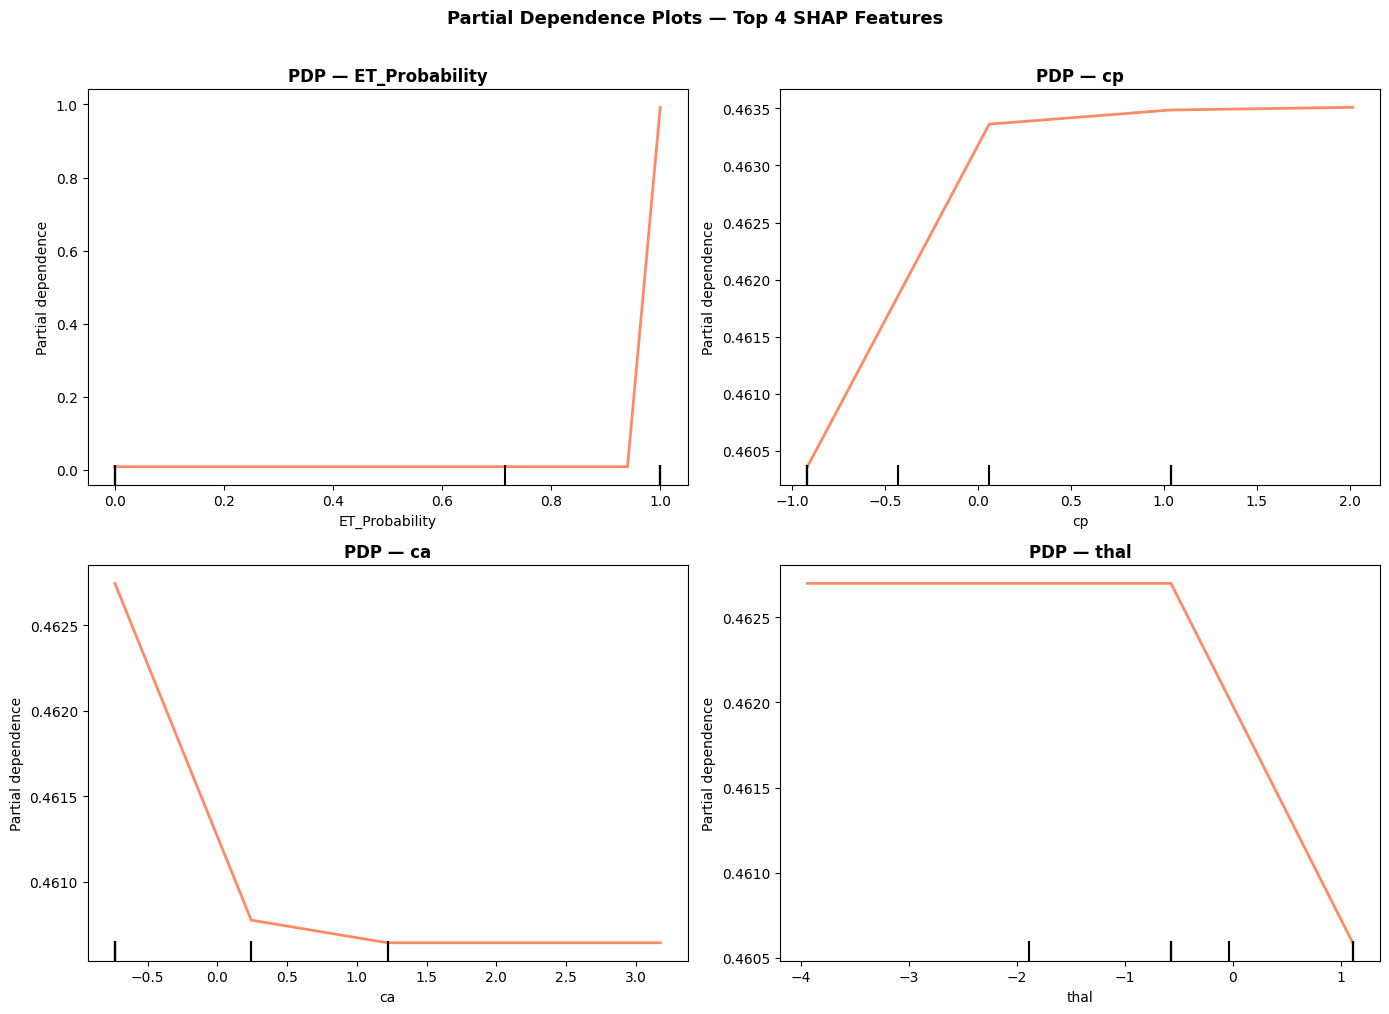

In [ ]:
mean_abs_shap = np.abs(sv_xgb).mean(axis=0)
top4_idx      = np.argsort(mean_abs_shap)[::-1][:4]
top4_features = [HYBRID_NAMES[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), top4_features):
    PartialDependenceDisplay.from_estimator(
        xgb_model, X_test_h, features=[HYBRID_NAMES.index(feat)],
        feature_names=HYBRID_NAMES, ax=ax,
        pd_line_kw={'color': '#ff8a65', 'lw': 2}
    )
    ax.set_title(f'PDP — {feat}', fontweight='bold')

plt.suptitle('Partial Dependence Plots — Top 4 SHAP Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pdp_top4.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 8. Medical Analysis — Clinical Insights

| Subsection | Clinical Question |
|---|---|
| 8a | Which features are the strongest disease indicators? |
| 8b | How do features differ between diseased and healthy patients? |
| 8c | What clinical thresholds does the model use? |
| 8d | What does each chest pain type, ST slope, thal, and ca value signal? |
| 8e | How do features interact clinically? |
| 8f | What do high-risk vs low-risk patient profiles look like? |
| 8g | Plain-language clinical report for individual patients |

### Setup — Reconstruct Unscaled Data

In [ ]:
df_test_raw = pd.DataFrame(scaler.inverse_transform(X_test_scaled), columns=FEATURE_COLS)
df_test_raw['target']     = y_test
df_test_raw['pred_prob']  = xgb_prob
df_test_raw['pred_label'] = xgb_pred
df_test_raw['correct']    = (xgb_pred == y_test).astype(int)

CP_LABELS     = {1:'Typical Angina', 2:'Atypical Angina',
                 3:'Non-anginal Pain', 4:'Asymptomatic'}
SLOPE_LABELS  = {1:'Upsloping', 2:'Flat', 3:'Downsloping'}
RESTECG_LABELS= {0:'Normal', 1:'ST-T Abnormality', 2:'LV Hypertrophy'}
THAL_LABELS   = {3:'Normal', 6:'Fixed Defect', 7:'Reversible Defect'}

df_test_raw['cp_label']     = df_test_raw['cp'].round().map(CP_LABELS)
df_test_raw['slope_label']  = df_test_raw['slope'].round().map(SLOPE_LABELS)
df_test_raw['thal_label']   = df_test_raw['thal'].round().map(THAL_LABELS)
df_test_raw['restecg_label']= df_test_raw['restecg'].round().map(RESTECG_LABELS)
df_test_raw['diagnosis']    = df_test_raw['target'].map({0:'No Disease', 1:'Disease'})

print("Unscaled test set ready:", df_test_raw.shape)

Unscaled test set ready: (308, 22)


### 8a. Clinically Ranked Feature Importance

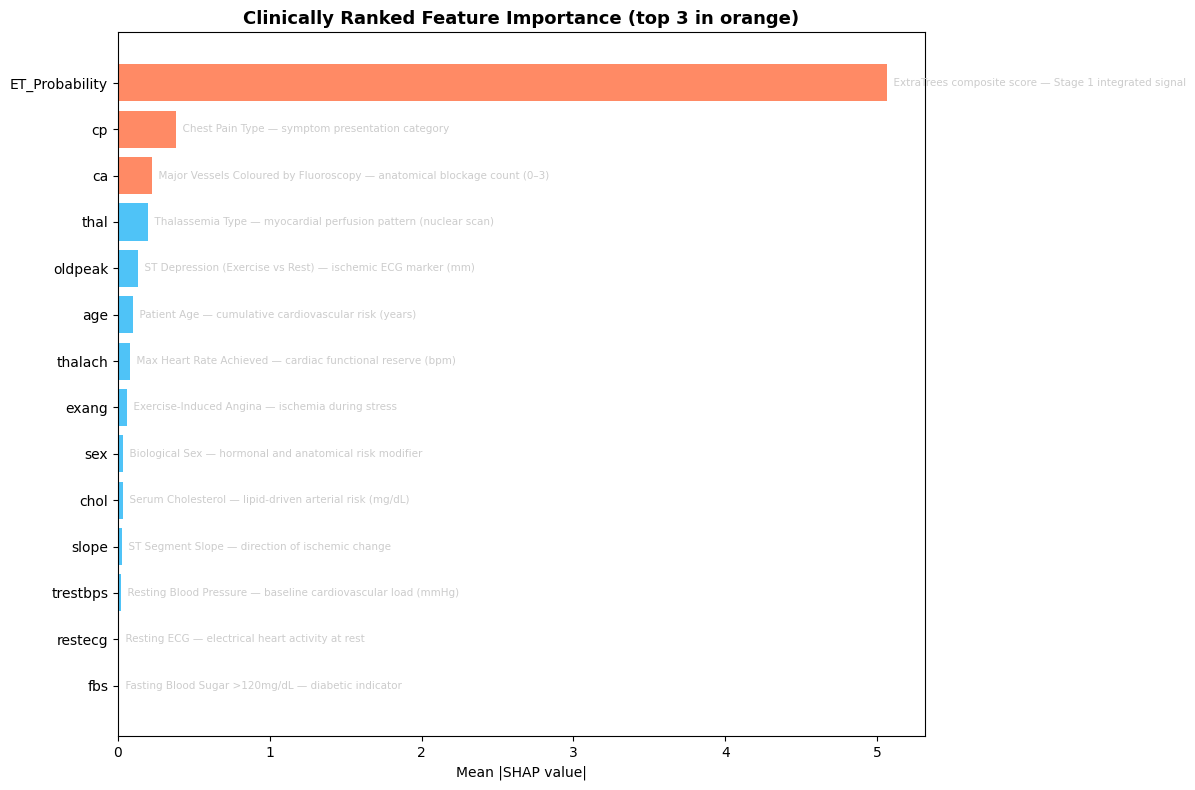

In [ ]:
CLINICAL_DESC = {
    'age'      : 'Patient Age — cumulative cardiovascular risk (years)',
    'sex'      : 'Biological Sex — hormonal and anatomical risk modifier',
    'cp'       : 'Chest Pain Type — symptom presentation category',
    'trestbps' : 'Resting Blood Pressure — baseline cardiovascular load (mmHg)',
    'chol'     : 'Serum Cholesterol — lipid-driven arterial risk (mg/dL)',
    'fbs'      : 'Fasting Blood Sugar >120mg/dL — diabetic indicator',
    'restecg'  : 'Resting ECG — electrical heart activity at rest',
    'thalach'  : 'Max Heart Rate Achieved — cardiac functional reserve (bpm)',
    'exang'    : 'Exercise-Induced Angina — ischemia during stress',
    'oldpeak'  : 'ST Depression (Exercise vs Rest) — ischemic ECG marker (mm)',
    'slope'    : 'ST Segment Slope — direction of ischemic change',
    'ca'       : 'Major Vessels Coloured by Fluoroscopy — anatomical blockage count (0–3)',
    'thal'     : 'Thalassemia Type — myocardial perfusion pattern (nuclear scan)',
    'ET_Probability': 'ExtraTrees composite score — Stage 1 integrated signal',
}

mean_shap   = np.abs(sv_xgb).mean(axis=0)
shap_series = pd.Series(mean_shap, index=HYBRID_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors  = ['#ff8a65' if i >= len(shap_series)-3 else '#4fc3f7'
           for i in range(len(shap_series))]
ax.barh(range(len(shap_series)), shap_series.values, color=colors, edgecolor='none')
ax.set_yticks(range(len(shap_series)))
ax.set_yticklabels(shap_series.index, fontsize=10)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Clinically Ranked Feature Importance (top 3 in orange)',
             fontsize=13, fontweight='bold')
for i, feat in enumerate(shap_series.index):
    ax.text(shap_series.values[i]+0.001, i,
            f'  {CLINICAL_DESC.get(feat,"")}',
            va='center', fontsize=7.5, color='#cccccc')
plt.tight_layout()
plt.savefig('medical_feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 8b. Clinical Feature Distributions — Disease vs No Disease

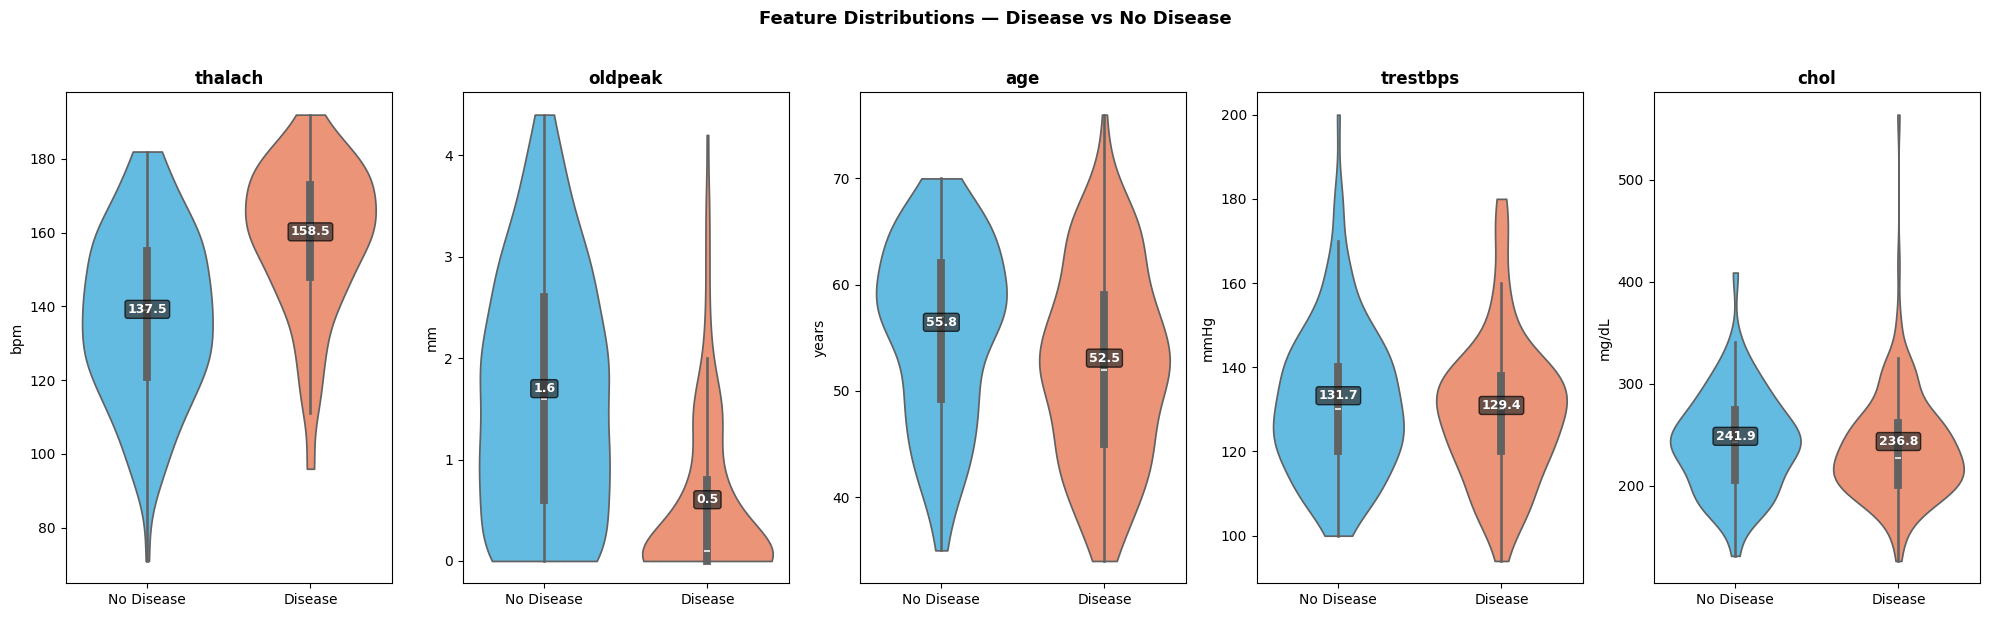

In [ ]:
top_continuous = ['thalach', 'oldpeak', 'age', 'trestbps', 'chol']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
units = {'thalach':'bpm','oldpeak':'mm','age':'years','trestbps':'mmHg','chol':'mg/dL'}

for ax, feat in zip(axes, top_continuous):
    sns.violinplot(data=df_test_raw, x='diagnosis', y=feat,
                   palette={'No Disease':'#4fc3f7','Disease':'#ff8a65'},
                   ax=ax, inner='box', cut=0)
    for i, grp in enumerate(['No Disease','Disease']):
        mean_val = df_test_raw[df_test_raw['diagnosis']==grp][feat].mean()
        ax.text(i, mean_val, f'{mean_val:.1f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9, color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#333', alpha=0.7))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(units.get(feat,''))

plt.suptitle('Feature Distributions — Disease vs No Disease',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('medical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 8c. Clinical Decision Thresholds

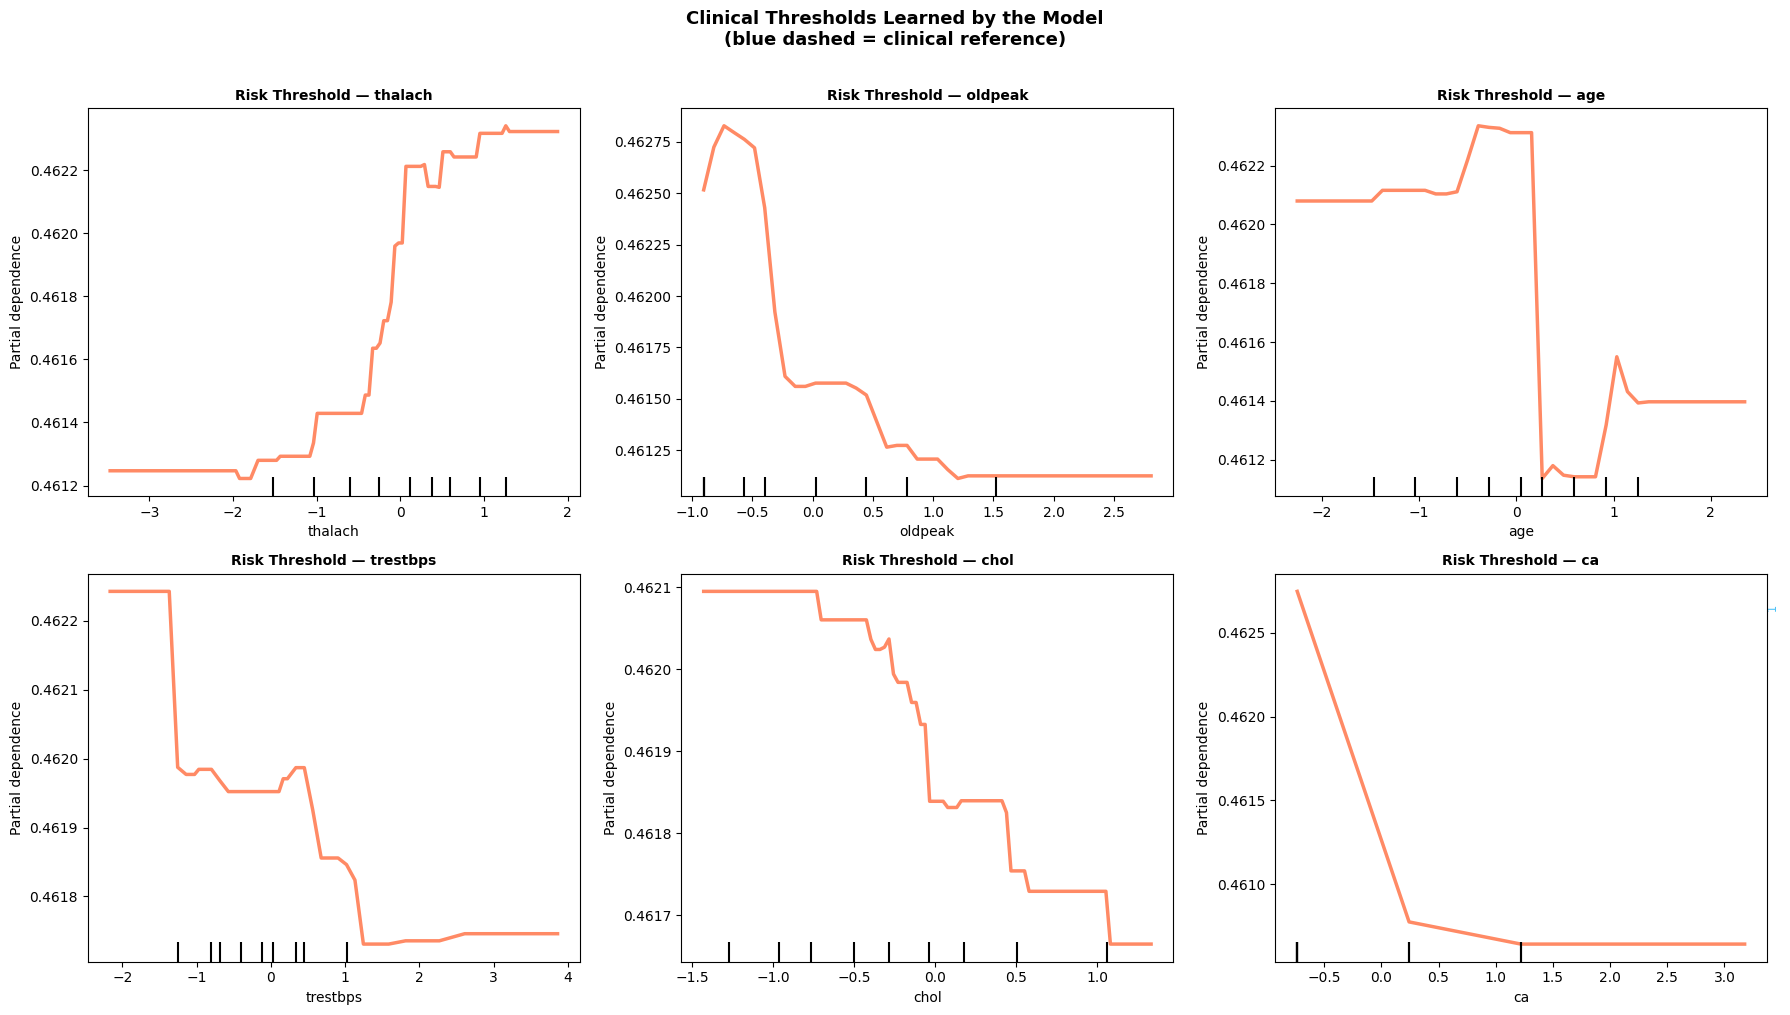

In [ ]:
CLINICAL_THRESHOLDS = {
    'thalach' : [(150, 'bpm',  'Chronotropic threshold')],
    'oldpeak' : [(1.5, 'mm',   'Ischemic threshold'), (3.0, 'mm', 'Severe ischemia')],
    'age'     : [(55,  'yrs',  'Risk inflection point')],
    'trestbps': [(140, 'mmHg', 'Stage 1 hypertension')],
    'chol'    : [(240, 'mg/dL','Borderline-high')],
    'ca'      : [(1,   '',     '≥1 vessel: significant CAD')],
}

threshold_features = ['thalach','oldpeak','age','trestbps','chol','ca']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), threshold_features):
    PartialDependenceDisplay.from_estimator(
        xgb_model, X_test_h,
        features=[HYBRID_NAMES.index(feat)],
        feature_names=HYBRID_NAMES, ax=ax,
        pd_line_kw={'color':'#ff8a65','lw':2.5}
    )
    for ref_val, unit, label in CLINICAL_THRESHOLDS.get(feat, []):
        ax.axvline(ref_val, linestyle='--', color='#4fc3f7', lw=1.5, alpha=0.8)
        ax.text(ref_val, ax.get_ylim()[1]*0.92, f' {ref_val}{unit}',
                color='#4fc3f7', fontsize=8.5, rotation=90, va='top')
        ax.text(0.02, 0.05, label, transform=ax.transAxes, fontsize=8,
                color='#cccccc',
                bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.7))
    ax.set_title(f'Risk Threshold — {feat}', fontweight='bold', fontsize=10)
    ax.set_ylabel('P(Disease)')

plt.suptitle('Clinical Thresholds Learned by the Model\n(blue dashed = clinical reference)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('medical_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

### 8d. Categorical Risk Analysis — CP, ST Slope, Thal & CA
`ca` and `thal` are the two features added in this schema. Both carry strong anatomical/physiological signal.

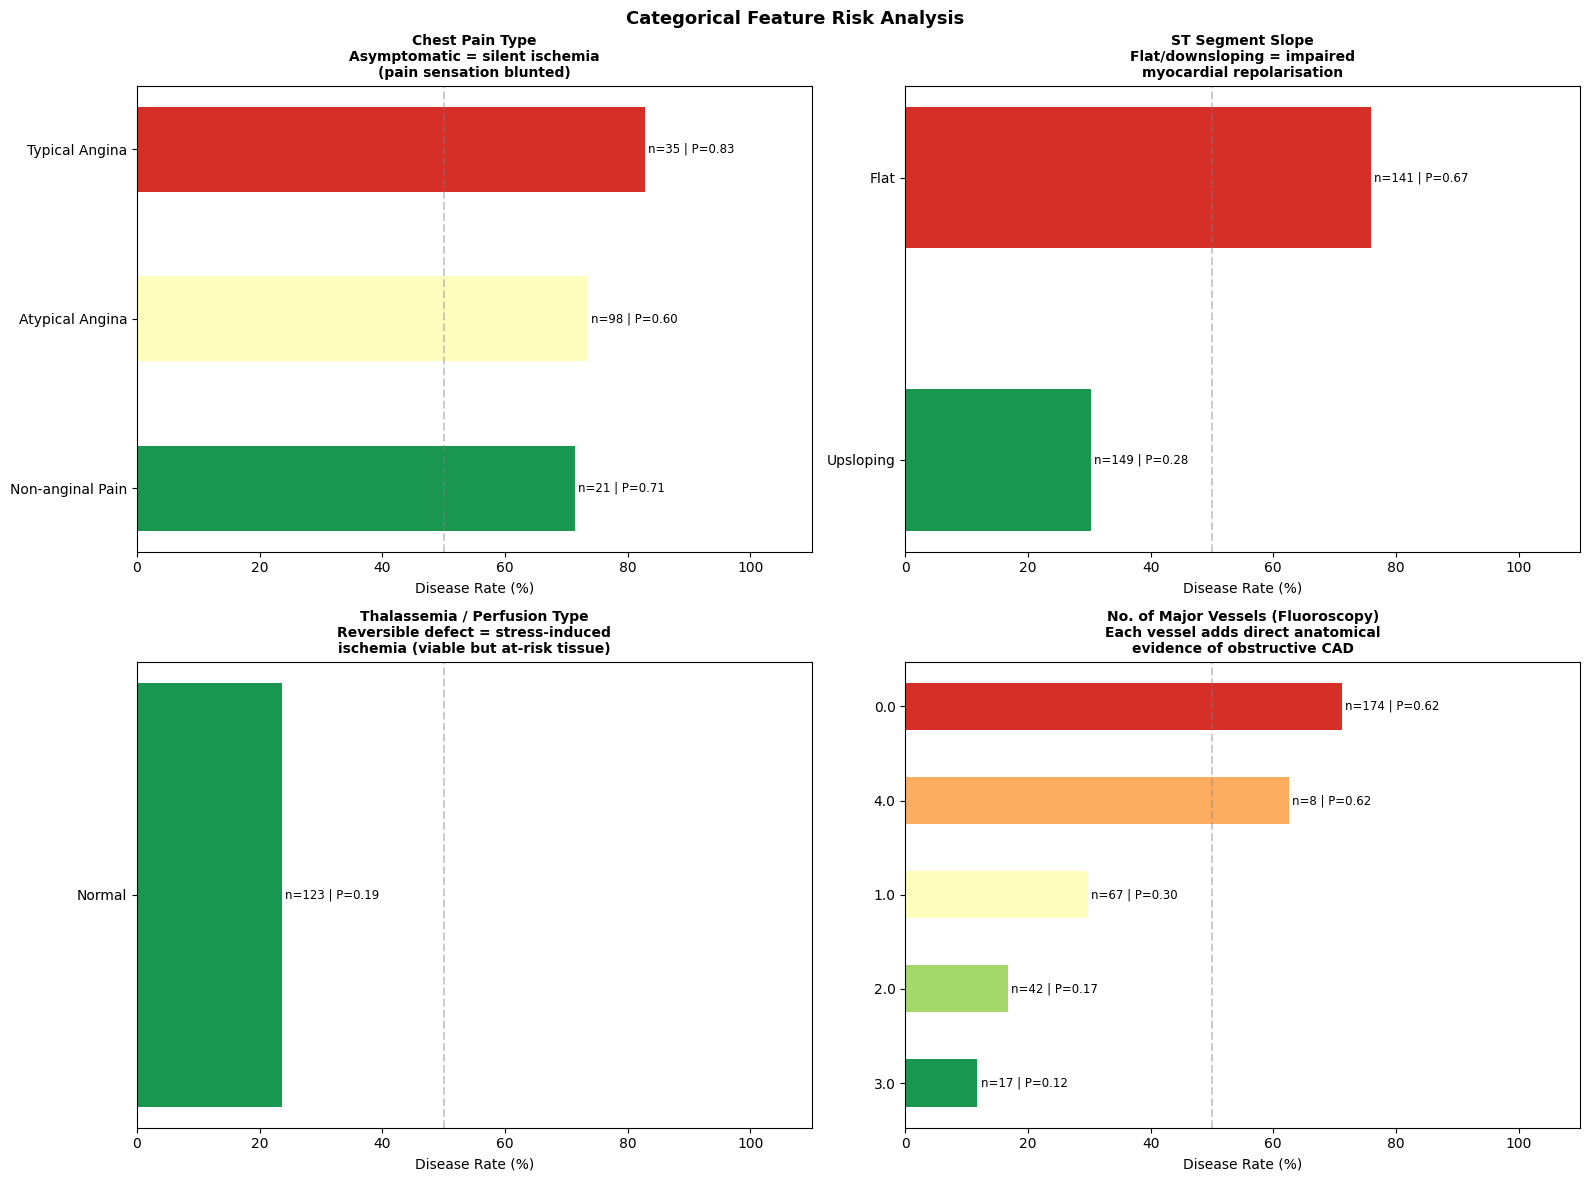

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cat_configs = [
    ('cp_label',   'Chest Pain Type',
     'Asymptomatic = silent ischemia\n(pain sensation blunted)'),
    ('slope_label','ST Segment Slope',
     'Flat/downsloping = impaired\nmyocardial repolarisation'),
    ('thal_label', 'Thalassemia / Perfusion Type',
     'Reversible defect = stress-induced\nischemia (viable but at-risk tissue)'),
    ('ca',         'No. of Major Vessels (Fluoroscopy)',
     'Each vessel adds direct anatomical\nevidence of obstructive CAD'),
]

for ax, (col, title, note) in zip(axes.flatten(), cat_configs):
    risk = df_test_raw.groupby(col).agg(
        disease_rate=('target','mean'),
        count=('target','size'),
        mean_pred=('pred_prob','mean')
    ).reset_index().sort_values('disease_rate', ascending=True)

    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(risk)))
    bars   = ax.barh(risk[col].astype(str), risk['disease_rate']*100,
                     color=colors, edgecolor='none', height=0.5)
    for bar, (_, row) in zip(bars, risk.iterrows()):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                f"n={int(row['count'])} | P={row['mean_pred']:.2f}",
                va='center', fontsize=8.5)
    ax.set_xlabel('Disease Rate (%)')
    ax.set_xlim(0, 110)
    ax.axvline(50, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(f'{title}\n{note}', fontweight='bold', fontsize=10)

plt.suptitle('Categorical Feature Risk Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('medical_categorical_risk.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical interpretation of `ca` and `thal`:**

- **`ca` (fluoroscopy vessel count):** Each additional major vessel with detectable calcium/narrowing represents a separate territory of obstructive coronary artery disease. The model correctly learns a near-monotonic increase in risk from ca=0 → ca=3, reflecting direct anatomical evidence of atherosclerotic burden.

- **`thal` (thalassemia / nuclear perfusion scan):** This encodes myocardial perfusion patterns. A *Reversible Defect* (value=7) means the myocardium shows reduced perfusion under stress but recovers at rest — classic stress-induced ischemia from a flow-limiting stenosis. A *Fixed Defect* (value=6) means permanent damage (prior infarct). *Normal* (value=3) is protective. The model assigns highest risk to reversible defects — the most clinically actionable finding.

### 8e. Clinical Feature Interactions

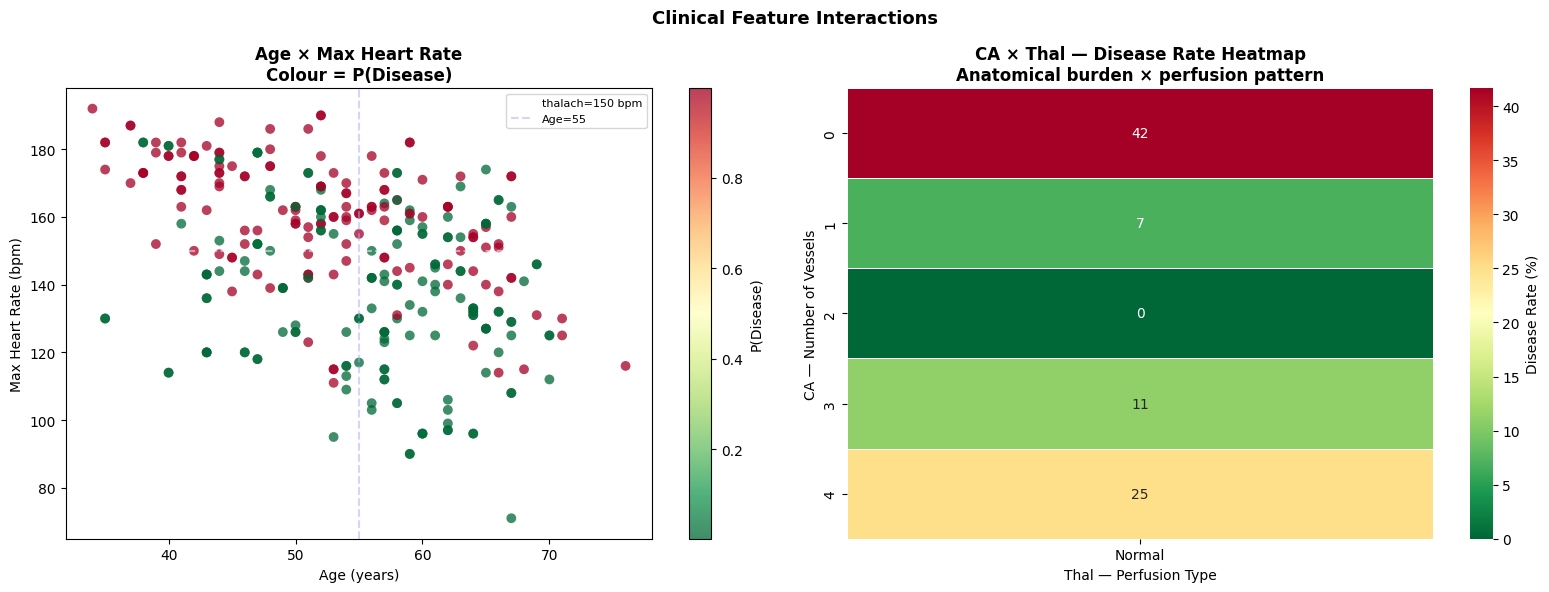

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age × Max Heart Rate
sc1 = axes[0].scatter(df_test_raw['age'], df_test_raw['thalach'],
                      c=df_test_raw['pred_prob'], cmap='RdYlGn_r',
                      s=50, alpha=0.75, edgecolors='none')
plt.colorbar(sc1, ax=axes[0], label='P(Disease)')
axes[0].axhline(150, linestyle='--', color='white', alpha=0.5, lw=1.5,
                label='thalach=150 bpm')
axes[0].axvline(55, linestyle='--', color='#aaaaff', alpha=0.5, lw=1.5,
                label='Age=55')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Max Heart Rate (bpm)')
axes[0].set_title('Age × Max Heart Rate\nColour = P(Disease)',
                  fontweight='bold')
axes[0].legend(fontsize=8)

# CA × Thal (anatomical × perfusion)
ca_thal = df_test_raw.groupby(
    [df_test_raw['ca'].round().astype(int),
     df_test_raw['thal_label']]
)['target'].mean().unstack(fill_value=0) * 100

sns.heatmap(ca_thal, ax=axes[1], annot=True, fmt='.0f',
            cmap='RdYlGn_r', linewidths=0.5,
            cbar_kws={'label':'Disease Rate (%)'})
axes[1].set_xlabel('Thal — Perfusion Type')
axes[1].set_ylabel('CA — Number of Vessels')
axes[1].set_title('CA × Thal — Disease Rate Heatmap\nAnatomical burden × perfusion pattern',
                  fontweight='bold')

plt.suptitle('Clinical Feature Interactions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('medical_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

**CA × Thal heatmap interpretation:** This is the most clinically powerful interaction in the dataset.  
- Bottom-right quadrant (high ca + reversible defect) = highest disease rate — both anatomical and functional evidence of ischemia present simultaneously  
- Top-left quadrant (ca=0 + normal thal) = lowest disease rate — no structural or perfusion abnormality  
The gradient across the heatmap represents the additive diagnostic value of combining invasive (fluoroscopy) and non-invasive (nuclear scan) testing.

### 8f. Patient Risk Profiling

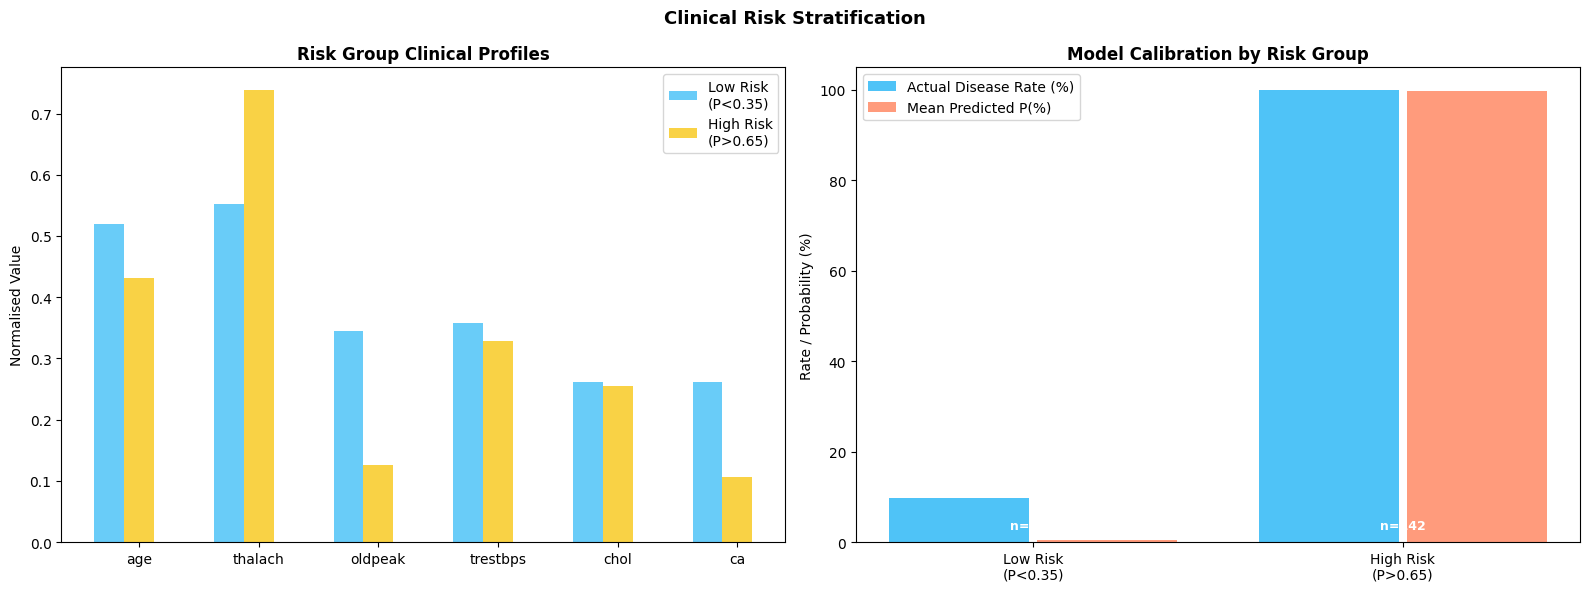

In [ ]:
df_test_raw['risk_group'] = pd.cut(
    df_test_raw['pred_prob'], bins=[0, 0.35, 0.65, 1.0],
    labels=['Low Risk\n(P<0.35)', 'Borderline\n(0.35–0.65)', 'High Risk\n(P>0.65)']
)

profile_features = ['age','thalach','oldpeak','trestbps','chol','ca']
profile = df_test_raw.groupby('risk_group', observed=True)[profile_features].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x, width = np.arange(len(profile_features)), 0.25
colors_risk = ['#4fc3f7','#f9ca24','#ff8a65']
for i, (grp, color) in enumerate(zip(profile.index, colors_risk)):
    if grp in profile.index:
        norm = (profile.loc[grp] - df_test_raw[profile_features].min()) /                (df_test_raw[profile_features].max() - df_test_raw[profile_features].min())
        axes[0].bar(x + i*width, norm, width, label=str(grp),
                    color=color, edgecolor='none', alpha=0.85)
axes[0].set_xticks(x+width); axes[0].set_xticklabels(profile_features)
axes[0].set_ylabel('Normalised Value')
axes[0].set_title('Risk Group Clinical Profiles', fontweight='bold')
axes[0].legend()

grp_acc = df_test_raw.groupby('risk_group', observed=True).agg(
    disease_rate=('target','mean'),
    mean_pred=('pred_prob','mean'),
    count=('target','size')
).reset_index()

x2 = np.arange(len(grp_acc))
axes[1].bar(x2-0.2, grp_acc['disease_rate']*100, 0.38,
            label='Actual Disease Rate (%)', color='#4fc3f7', edgecolor='none')
axes[1].bar(x2+0.2, grp_acc['mean_pred']*100, 0.38,
            label='Mean Predicted P(%)', color='#ff8a65', edgecolor='none', alpha=0.85)
axes[1].set_xticks(x2); axes[1].set_xticklabels(grp_acc['risk_group'])
axes[1].set_ylabel('Rate / Probability (%)')
axes[1].set_title('Model Calibration by Risk Group', fontweight='bold')
axes[1].legend()
for i, row in grp_acc.iterrows():
    axes[1].text(i, 3, f"n={int(row['count'])}", ha='center',
                 fontsize=9, color='white', fontweight='bold')

plt.suptitle('Clinical Risk Stratification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('medical_risk_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 8g. Individual Patient Clinical Report

In [ ]:
CLINICAL_MEANING = {
    'cp'      : {'high':'Asymptomatic/atypical — silent ischemia pattern',
                 'low' :'Typical angina — classic ischemic symptoms'},
    'thalach' : {'high':'Good max HR — adequate chronotropic response',
                 'low' :'Reduced max HR — chronotropic incompetence'},
    'oldpeak' : {'high':'Significant ST depression — ischemic ECG response',
                 'low' :'Minimal ST depression — normal repolarisation'},
    'slope'   : {'high':'Flat/downsloping ST — abnormal repolarisation',
                 'low' :'Upsloping ST — normal exercise response'},
    'exang'   : {'high':'Exercise angina present — symptomatic ischemia',
                 'low' :'No exercise angina'},
    'ca'      : {'high':'Multiple vessels affected — extensive anatomical CAD',
                 'low' :'No/few vessels — minimal anatomical burden'},
    'thal'    : {'high':'Reversible/fixed defect — perfusion abnormality on scan',
                 'low' :'Normal perfusion — no myocardial ischemia on scan'},
    'age'     : {'high':'Older — higher cumulative cardiovascular risk',
                 'low' :'Younger — lower baseline risk'},
    'trestbps': {'high':'Elevated resting BP — increased cardiac afterload',
                 'low' :'Normal resting BP'},
    'chol'    : {'high':'Elevated cholesterol — atherogenic lipid profile',
                 'low' :'Normal/low cholesterol'},
    'sex'     : {'high':'Male — higher baseline CAD prevalence',
                 'low' :'Female — lower pre-menopausal CAD risk'},
    'fbs'     : {'high':'FBS >120 mg/dL — diabetic range, vascular amplifier',
                 'low' :'Normal fasting blood sugar'},
    'restecg' : {'high':'Abnormal resting ECG — baseline electrical disturbance',
                 'low' :'Normal resting ECG'},
    'ET_Probability': {'high':'ETC composite score high — integrated multi-feature risk',
                       'low' :'ETC composite score low — integrated features suggest lower risk'},
}

def generate_clinical_report(patient_idx):
    raw       = df_test_raw.iloc[patient_idx]
    shap_row  = sv_xgb[patient_idx]
    top_feats = sorted(zip(HYBRID_NAMES, shap_row), key=lambda x: abs(x[1]), reverse=True)
    prob, actual, pred = xgb_prob[patient_idx], y_test[patient_idx], xgb_pred[patient_idx]
    risk = 'HIGH' if prob>0.65 else ('BORDERLINE' if prob>0.35 else 'LOW')

    print("=" * 65)
    print(f"  CLINICAL REPORT — Patient {patient_idx}")
    print("=" * 65)
    print(f"  Actual    : {'Heart Disease' if actual==1 else 'No Heart Disease'}")
    print(f"  Predicted : {'Heart Disease' if pred==1 else 'No Heart Disease'}")
    print(f"  P(Disease): {prob:.1%}  |  Risk Level: {risk}")
    print()
    print("  KEY CLINICAL VALUES:")
    print(f"    Age              : {raw['age']:.0f} yrs")
    print(f"    Sex              : {'Male' if raw['sex']>0.5 else 'Female'}")
    print(f"    Resting BP       : {raw['trestbps']:.0f} mmHg")
    print(f"    Cholesterol      : {raw['chol']:.0f} mg/dL")
    print(f"    Max Heart Rate   : {raw['thalach']:.0f} bpm")
    print(f"    ST Depression    : {raw['oldpeak']:.2f} mm")
    print(f"    Chest Pain Type  : {CP_LABELS.get(round(raw['cp']),'?')}")
    print(f"    ST Slope         : {SLOPE_LABELS.get(round(raw['slope']),'?')}")
    print(f"    Exercise Angina  : {'Yes' if raw['exang']>0.5 else 'No'}")
    print(f"    Vessels (CA)     : {raw['ca']:.0f}")
    print(f"    Thal / Perfusion : {THAL_LABELS.get(round(raw['thal']),'?')}")
    print()
    print("  TOP DRIVERS  (+ = raises risk | - = lowers risk):")
    for rank, (feat, val) in enumerate(top_feats[:6], 1):
        direction = 'high' if val > 0 else 'low'
        meaning   = CLINICAL_MEANING.get(feat, {}).get(direction, '')
        print(f"  {rank}. [{'+'if val>0 else '-'}{abs(val):.4f}] {feat}")
        if meaning: print(f"         → {meaning}")
    print()
    print("  SUMMARY:")
    if prob > 0.65:
        print("  HIGH-RISK profile. Significant ischemic burden indicated.")
        print("  Recommend: further investigation (stress test / angiography).")
    elif prob > 0.35:
        print("  BORDERLINE profile. Mixed protective and ischemic signals.")
        print("  Recommend: close monitoring and risk factor management.")
    else:
        print("  LOW-RISK profile. Protective factors predominate.")
        print("  Recommend: routine preventive care.")
    print("=" * 65)

# Run for 3 clinically interesting patients
for idx, label in [
    (int(pd.Series(xgb_prob).idxmax()), 'Most confident HIGH RISK'),
    (int(pd.Series(xgb_prob).idxmin()), 'Most confident LOW RISK'),
    (int(np.where(ET_pred != xgb_pred)[0][0]), 'ETC–XGB DISAGREEMENT'),
]:
    print(f"\n>>> {label}")
    generate_clinical_report(idx)


>>> Most confident HIGH RISK
  CLINICAL REPORT — Patient 52
  Actual    : Heart Disease
  Predicted : Heart Disease
  P(Disease): 99.8%  |  Risk Level: HIGH

  KEY CLINICAL VALUES:
    Age              : 44 yrs
    Sex              : Male
    Resting BP       : 120 mmHg
    Cholesterol      : 220 mg/dL
    Max Heart Rate   : 170 bpm
    ST Depression    : 0.00 mm
    Chest Pain Type  : Typical Angina
    ST Slope         : Flat
    Exercise Angina  : No
    Vessels (CA)     : 0
    Thal / Perfusion : ?

  TOP DRIVERS  (+ = raises risk | - = lowers risk):
  1. [+5.0479] ET_Probability
         → ETC composite score high — integrated multi-feature risk
  2. [+0.3050] cp
         → Asymptomatic/atypical — silent ischemia pattern
  3. [+0.2123] ca
         → Multiple vessels affected — extensive anatomical CAD
  4. [+0.1775] thal
         → Reversible/fixed defect — perfusion abnormality on scan
  5. [+0.1686] age
         → Older — higher cumulative cardiovascular risk
  6. [+0.0936] old

### 8h. SHAP Dependence with Clinical Reference Values

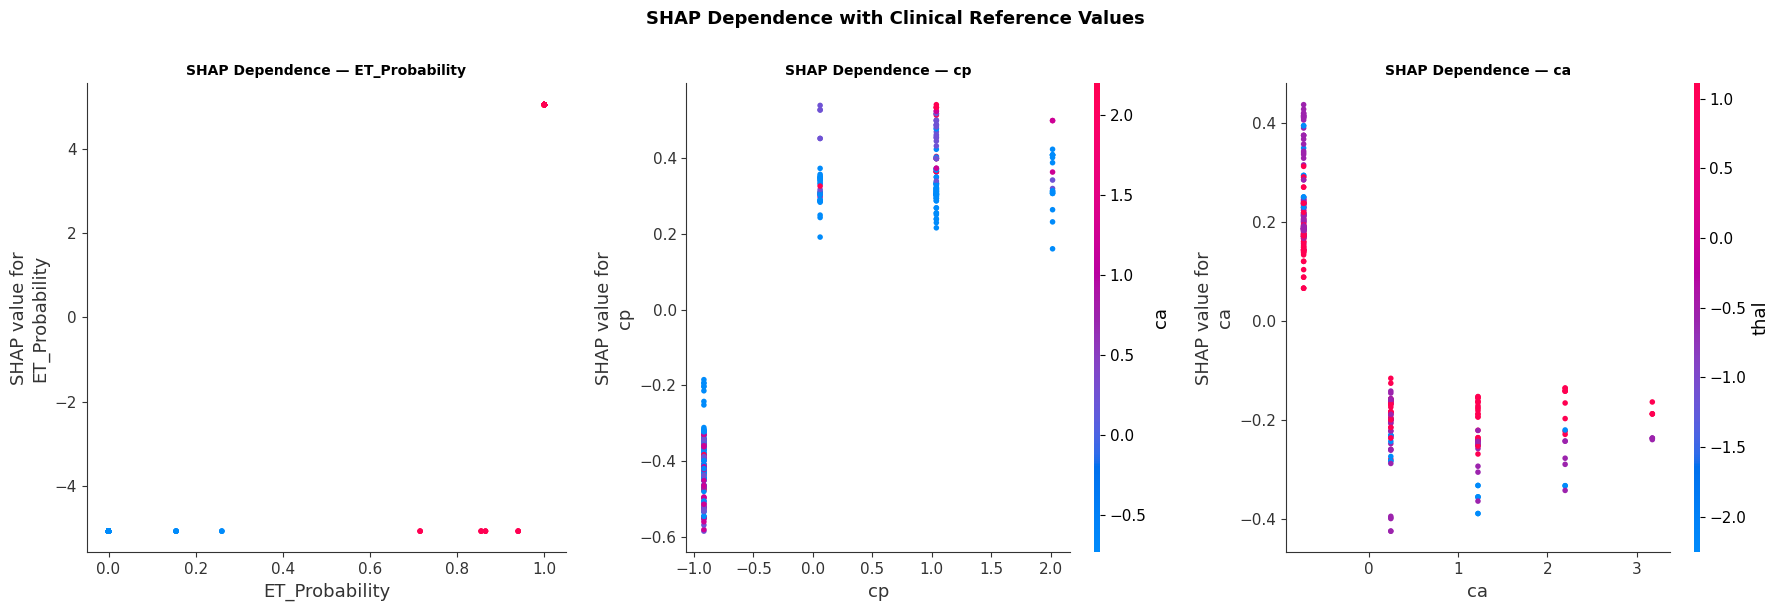

In [ ]:
CLINICAL_REFS = {
    'thalach' : [(150,'Chronotropic threshold'),(100,'Severely reduced')],
    'oldpeak' : [(1.0,'Mild ischemia'),(2.0,'Moderate'),(4.0,'Severe')],
    'age'     : [(45,'CAD risk onset'),(65,'High-risk bracket')],
    'ca'      : [(1,'≥1 vessel: CAD present'),(2,'Multi-vessel disease')],
    'thal'    : [(5.5,'Threshold normal→defect')],
    'trestbps': [(120,'Normal'),(140,'Stage 1 HTN')],
    'chol'    : [(200,'Desirable'),(240,'Borderline-high')],
    'slope'   : [(1.5,'Upsloping→flat transition')],
}

top3 = [HYBRID_NAMES[i] for i in np.argsort(np.abs(sv_xgb).mean(axis=0))[::-1][:3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, sv_xgb, X_test_h,
                         feature_names=HYBRID_NAMES, ax=ax, show=False)
    for ref_val, ref_label in CLINICAL_REFS.get(feat, []):
        ax.axvline(ref_val, linestyle='--', color='white', alpha=0.6, lw=1.2)
        ax.text(ref_val, ax.get_ylim()[1]*0.92, f' {ref_label}',
                color='white', fontsize=7.5, rotation=90, va='top')
    ax.set_title(f'SHAP Dependence — {feat}', fontweight='bold', fontsize=10)

plt.suptitle('SHAP Dependence with Clinical Reference Values',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('medical_shap_clinical.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary — All Output Files

**Performance**
```
performance_cm_roc.png
```
**Stage 1 — ETC**
```
etc_feature_importance.png
etc_shap_beeswarm.png
etc_waterfall_p5.png
```
**Stage 2 — XGB**
```
xgb_feature_importance_gain.png
xgb_shap_beeswarm.png
xgb_waterfall_p5.png
```
**Pipeline**
```
pipeline_shap_comparison.png
pipeline_et_contribution.png
pipeline_agreement.png
pipeline_dual_waterfall_p*.png
pipeline_lime_dual_p*.png
```
**PDP**
```
pdp_top4.png
```
**Medical Analysis**
```
medical_feature_ranking.png
medical_distributions.png
medical_thresholds.png
medical_categorical_risk.png
medical_interactions.png
medical_risk_profiles.png
medical_shap_clinical.png
```

In [ ]:
import zipfile
import glob
from google.colab import files
import os

# Define the name of the zip file
zip_filename = 'all_notebook_images.zip'

# Find all .png files in the /content/ directory
image_files = glob.glob('/content/*.png')

if not image_files:
    print("No image files (.png) found in the /content/ directory.")
else:
    # Create a zip file
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for file_path in image_files:
            # Add each image file to the zip archive
            # arcname is used to store the file within the zip with only its filename
            zipf.write(file_path, arcname=os.path.basename(file_path))
    print(f"Successfully created '{zip_filename}' containing {len(image_files)} image(s).")

    # Download the zip file
    files.download(zip_filename)

Successfully created 'all_notebook_images.zip' containing 20 image(s).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>